# stockpy Quickstart — Encoder-Decoder Forecasting on AAPL

This notebook walks through the full stockpy `0.4.0` workflow on real stock data:

1. Load the bundled `stock/AAPL.csv` (OHLCV).
2. Chronologically split + scale.
3. Fit an `LSTMForecaster` that maps a `context_len` window of past observations to a `pred_len` window of future values.
4. Forecast the next few days, inverse-scale, and plot against the ground truth.
5. Persist and reload the model with safetensors.

Expected runtime: about a minute on CPU.

> All forecasters in `stockpy.forecasters` follow the same encoder-decoder contract: `predict()` returns an array of shape `(n_windows, pred_len, n_features)`. Swap `LSTMForecaster` for `GRUForecaster`, `BiLSTMForecaster`, `TCNForecaster`, `TransformerForecaster`, or `DMMForecaster` — the rest of the notebook stays the same.

In [9]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from stockpy.forecasters import LSTMForecaster
from stockpy.preprocessing import StandardScalerTransform
from stockpy.callbacks import PrintLog

torch.manual_seed(0)
np.random.seed(0)

## 1. Load AAPL

We keep the five OHLCV columns and drop `Adj Close` (redundant with `Close` for our purposes) and the `Date` index (used only for plotting).

In [10]:
df = (
    pd.read_csv("../stock/AAPL.csv", parse_dates=True, index_col="Date")
    .dropna(how="any")
)
feature_cols = ["Open", "High", "Low", "Close", "Volume"]
data = df[feature_cols].astype(np.float32)
print("shape:", data.shape)
data.head()

shape: (1569, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2017-01-03 00:00:00-05:00,28.950001,29.082500,28.690001,29.037500,115127600.0
2017-01-04 00:00:00-05:00,28.962500,29.127501,28.937500,29.004999,84472400.0
2017-01-05 00:00:00-05:00,28.980000,29.215000,28.952499,29.152500,88774400.0
2017-01-06 00:00:00-05:00,29.195000,29.540001,29.117500,29.477501,127007600.0
2017-01-09 00:00:00-05:00,29.487499,29.857500,29.485001,29.747499,134247600.0


## 2. Chronological train/test split + scaling

Time-series splits must be ordered — never shuffle. We fit the scaler on the training window only to avoid leaking statistics from the future. `StandardScalerTransform` mirrors its input library: numpy in → numpy out (and tensor in → tensor out), so we get back numpy arrays without any explicit conversion.

In [11]:
n_train = int(len(data) * 0.8)
X_train_raw = data.values[:n_train]
X_test_raw = data.values[n_train:]

scaler = StandardScalerTransform()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (1255, 5), test: (314, 5)


## 3. Define the forecaster

The model reads `context_len=30` past trading days and predicts the next `pred_len=5`. `TimeSeriesDataset` (used internally) requires `series_len >= context_len + pred_len`, so the choice is bounded by the test-set length.

In [12]:
CONTEXT_LEN = 90
PRED_LEN = 30

model = LSTMForecaster(
    context_len=CONTEXT_LEN,
    pred_len=PRED_LEN,
    rnn_size=64,
    hidden_size=64,
    num_layers=2,
    dropout=0.1,
)

## 4. Train

`y=X_train` is the auto-regressive setup: targets are the same series, sliced into the future window by `TimeSeriesDataset`. `train_split=None` disables validation splitting since the windowed dataset has fewer rows than the raw series — for production runs supply your own `ValidSplit` or held-out arrays.

In [13]:
model.fit(
    X_train,
    y=X_train,
    epochs=15,
    batch_size=32,
    lr=1e-3,
    optimizer=torch.optim.Adam,
    train_split=None,
    callbacks=[PrintLog()],
)

  epoch    train_loss     dur
-------  ------------  ------
      1        0.9251  0.7647
  epoch    train_loss     dur
-------  ------------  ------
      1        0.9251  0.7647
      2        0.3760  0.6271
      2        0.3760  0.6271
      3        0.9286  0.6446
      3        0.9286  0.6446
      4        0.3939  0.6845
      4        0.3939  0.6845
      5        0.3116  0.7307
      5        0.3116  0.7307
      6        0.2753  0.6034
      6        0.2753  0.6034
      7        0.2591  0.6124
      7        0.2591  0.6124
      8        0.2417  0.6162
      8        0.2417  0.6162
      9        0.2247  0.7478
      9        0.2247  0.7478
     10        0.2112  0.6538
     10        0.2112  0.6538
     11        0.2010  0.6317
     11        0.2010  0.6317
     12        0.1916  0.6174
     12        0.1916  0.6174
     13        0.1666  0.6689
     13        0.1666  0.6689
     14        0.1545  0.7229
     14        0.1545  0.7229
     15        0.1581  0.7007
     15   

<class 'stockpy.forecasters._lstm.LSTMForecaster'>[initialized](
  module_=LSTMModel(
    (encoder): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.1)
    (decoder): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.1)
    (output_proj): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=64, out_features=5, bias=True)
    )
  ),
)

## 5. Forecast the next 5 days

Take the last `context_len` rows of the test set as the encoder input, feed them through `predict`, and inverse-scale the result back to dollar units. The ground truth for comparison is the next `pred_len` rows.

In [14]:
context = X_test[-(CONTEXT_LEN + PRED_LEN) : -PRED_LEN]
actual = X_test_raw[-PRED_LEN:]

# predict() accepts a Dataset; wrap the single context window into one batch.
context_batch = torch.tensor(context).unsqueeze(0)
ds = torch.utils.data.TensorDataset(context_batch, torch.zeros(1, 1))

pred_scaled = model.predict(ds)
pred = scaler.inverse_transform(
    pred_scaled.reshape(-1, len(feature_cols))
).reshape(1, PRED_LEN, len(feature_cols))

close_idx = feature_cols.index("Close")
print("predicted Close:", pred[0, :, close_idx])
print("actual Close:   ", actual[:, close_idx])

predicted Close: [143.78494 145.68445 146.21255 146.30017 146.17812 145.9775  145.74852
 145.51157 145.276   145.0463  144.82434 144.61035 144.40378 144.20355
 144.00853 143.8175  143.6294  143.4432  143.25803 143.0731  142.88776
 142.70137 142.5134  142.3234  142.13084 141.93536 141.73654 141.53401
 141.32735 141.11618]
actual Close:    [153.2  155.33 153.71 152.55 148.48 148.91 149.4  146.71 147.92 147.41
 145.31 145.91 151.03 153.83 151.6  152.87 150.59 148.5  150.47 152.59
 152.99 155.85 155.   157.4  159.28 157.83 158.93 160.25 158.28 157.65]


## 6. Plot

Show the last 60 days of context plus the forecast vs. the actual future prices.

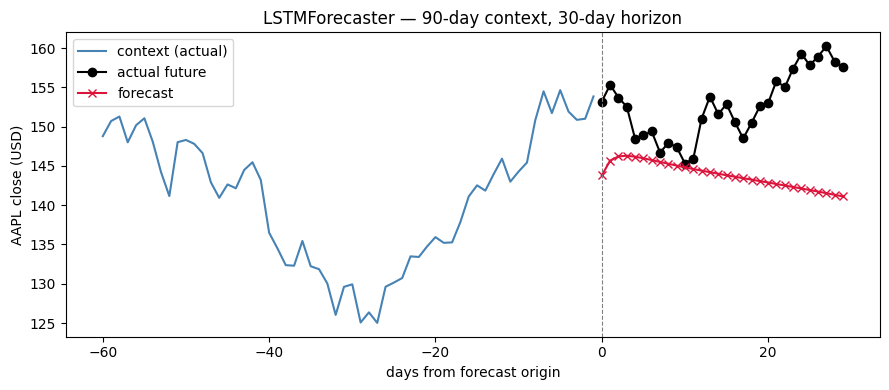

In [15]:
history_window = 60
history_close = X_test_raw[-(history_window + PRED_LEN) : -PRED_LEN, close_idx]

x_hist = np.arange(-history_window, 0)
x_future = np.arange(0, PRED_LEN)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_hist, history_close, label="context (actual)", color="steelblue")
ax.plot(x_future, actual[:, close_idx], label="actual future", color="black", marker="o")
ax.plot(x_future, pred[0, :, close_idx], label="forecast", color="crimson", marker="x")
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("days from forecast origin")
ax.set_ylabel("AAPL close (USD)")
ax.set_title(f"LSTMForecaster \u2014 {CONTEXT_LEN}-day context, {PRED_LEN}-day horizon")
ax.legend()
fig.tight_layout()
plt.show()

## 7. Save and reload (safetensors)

stockpy persists model parameters via [safetensors](https://github.com/huggingface/safetensors). To rebuild the model on a fresh process, instantiate it with the same hyperparameters, run a single `fit` call with `epochs=0` to trigger module initialization, then `load_params`.

In [16]:
ckpt = "aapl_lstm.safetensors"
model.save_params(f_params=ckpt, use_safetensors=True)

reloaded = LSTMForecaster(
    context_len=CONTEXT_LEN,
    pred_len=PRED_LEN,
    rnn_size=64,
    hidden_size=64,
    num_layers=2,
    dropout=0.1,
)
reloaded.fit(X_train, y=X_train, epochs=0, train_split=None, verbose=0)
reloaded.load_params(f_params=ckpt, use_safetensors=True)

preds_reloaded = reloaded.predict(ds)
np.testing.assert_allclose(pred_scaled, preds_reloaded, rtol=1e-5)
print("OK — reload matches original")

OK — reload matches original


## Where to go next

- Try a different forecaster: `from stockpy.forecasters import TransformerForecaster` — same `fit` / `predict` API.
- Use `DMMForecaster` for a probabilistic encoder-decoder (Pyro SVI under the hood).
- Add `Checkpoint` and `LRScheduler` from `stockpy.callbacks` for longer training runs.
- Increase `pred_len` for longer horizons — remember the `series_len >= context_len + pred_len` constraint.